In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/raw/01-hotel_bookings.csv')
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15


## 1. Calidad de Datos
Analizamos valores nulos, tipos de datos, duplicados y valores inconsistentes.

In [13]:
# 1.1 Tipos de datos
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

=== TIPOS DE DATOS ===
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent      

In [14]:
# 1.2 Nulos - tabla completa ordenada
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
nulos_df = nulos_df[nulos_df['nulos'] > 0].sort_values('porcentaje', ascending=False)
print("=== COLUMNAS CON VALORES NULOS ===")
display(nulos_df)

=== COLUMNAS CON VALORES NULOS ===


,nulos,porcentaje
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [15]:
# 1.3 Duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.2f}%)")

Filas duplicadas: 31994 (26.80%)


In [16]:
# 1.4 Valores únicos por columna (útil para detectar constantes)
print("=== VALORES ÚNICOS POR COLUMNA ===")
unicos = df.nunique().sort_values()
print(unicos)

=== VALORES ÚNICOS POR COLUMNA ===
hotel                                2
is_canceled                          2
is_repeated_guest                    2
arrival_date_year                    3
deposit_type                         3
reservation_status                   3
customer_type                        4
babies                               5
meal                                 5
distribution_channel                 5
children                             5
required_car_parking_spaces          5
total_of_special_requests            6
market_segment                       8
reserved_room_type                  10
arrival_date_month                  12
assigned_room_type                  12
adults                              14
previous_cancellations              15
stays_in_weekend_nights             17
booking_changes                     21
arrival_date_day_of_month           31
stays_in_week_nights                35
arrival_date_week_number            53
previous_bookings_not_cancele

In [17]:
# 1.5 Detectar columnas con un solo valor (constantes = inútiles para el modelo)
constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Columnas constantes: {constantes}")

Columnas constantes: []


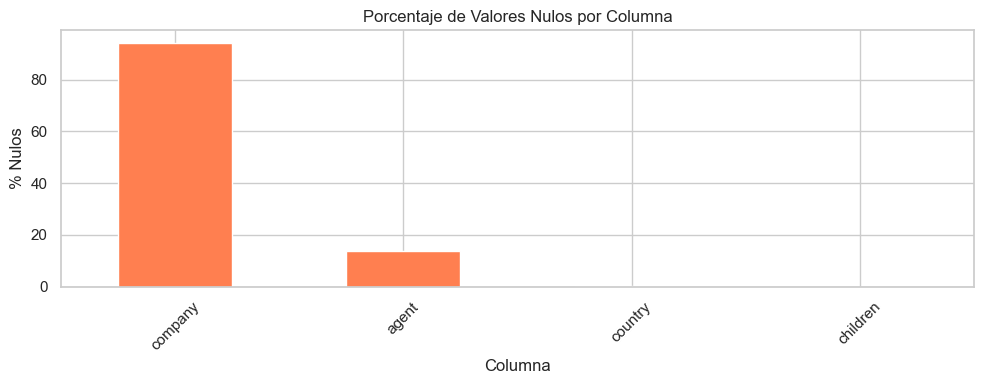

In [18]:
# 1.6 Visualización de nulos
plt.figure(figsize=(10, 4))
nulos_df['porcentaje'].plot(kind='bar', color='coral')
plt.title('Porcentaje de Valores Nulos por Columna')
plt.xlabel('Columna')
plt.ylabel('% Nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hallazgos — Calidad de Datos
- `company`: 94.3% nulos → columna con muy poca información, probablemente se descarte en preprocesamiento
- `agent`: 13.7% nulos → podría indicar reservas directas sin agente
- `country`: 0.4% nulos → porcentaje bajo, manejable con imputación
- `children`: 0.003% nulos → casi completo, fácil de imputar
- No se detectaron columnas constantes

## 2. Estadísticas Descriptivas
Exploramos la distribución de las variables numéricas y categóricas.

In [19]:
# 2.1 Resumen estadístico variables numéricas
print("=== VARIABLES NUMÉRICAS ===")
display(df.describe().T.round(2))

=== VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


In [20]:
# 2.2 Variables categóricas
print("=== VARIABLES CATEGÓRICAS ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} categorías")
    print(df[col].value_counts().head(5))

=== VARIABLES CATEGÓRICAS ===

hotel: 2 categorías
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

arrival_date_month: 12 categorías
arrival_date_month
August     13877
July       12661
May        11791
October    11160
April      11089
Name: count, dtype: int64

meal: 5 categorías
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

country: 177 categorías
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: count, dtype: int64

market_segment: 8 categorías
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Name: count, dtype: int64

distribution_channel: 5 categorías
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

reserved_room_type: 10 categorías
reserved_room_type
A    85994
D    1920

=== BALANCE DE CLASES: is_canceled ===
             count  porcentaje
is_canceled                   
0            75166       62.96
1            44224       37.04


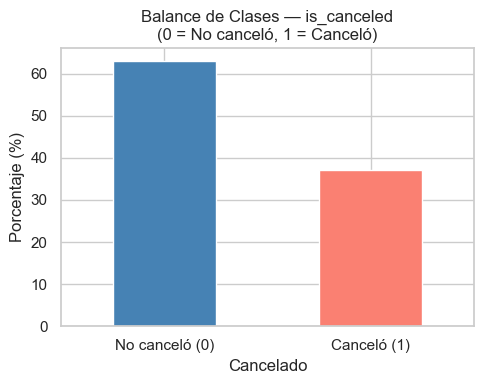

In [21]:
# 2.3 Balance de clases del target
print("=== BALANCE DE CLASES: is_canceled ===")
balance = df['is_canceled'].value_counts()
balance_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': balance, 'porcentaje': balance_pct.round(2)}))

plt.figure(figsize=(5, 4))
balance_pct.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Balance de Clases — is_canceled\n(0 = No canceló, 1 = Canceló)')
plt.xlabel('Cancelado')
plt.ylabel('Porcentaje (%)')
plt.xticks([0, 1], ['No canceló (0)', 'Canceló (1)'], rotation=0)
plt.tight_layout()
plt.show()

### Hallazgos — Balance de Clases
- Aproximadamente 63% de reservas NO se cancelaron y 37% SÍ se cancelaron
- Las clases están **moderadamente desbalanceadas** — en Sprint 2 se evaluará si aplicar técnicas de balanceo (SMOTE, undersampling)

## 3. Visualizaciones
Exploramos distribuciones de variables clave y su relación con el target `is_canceled`.

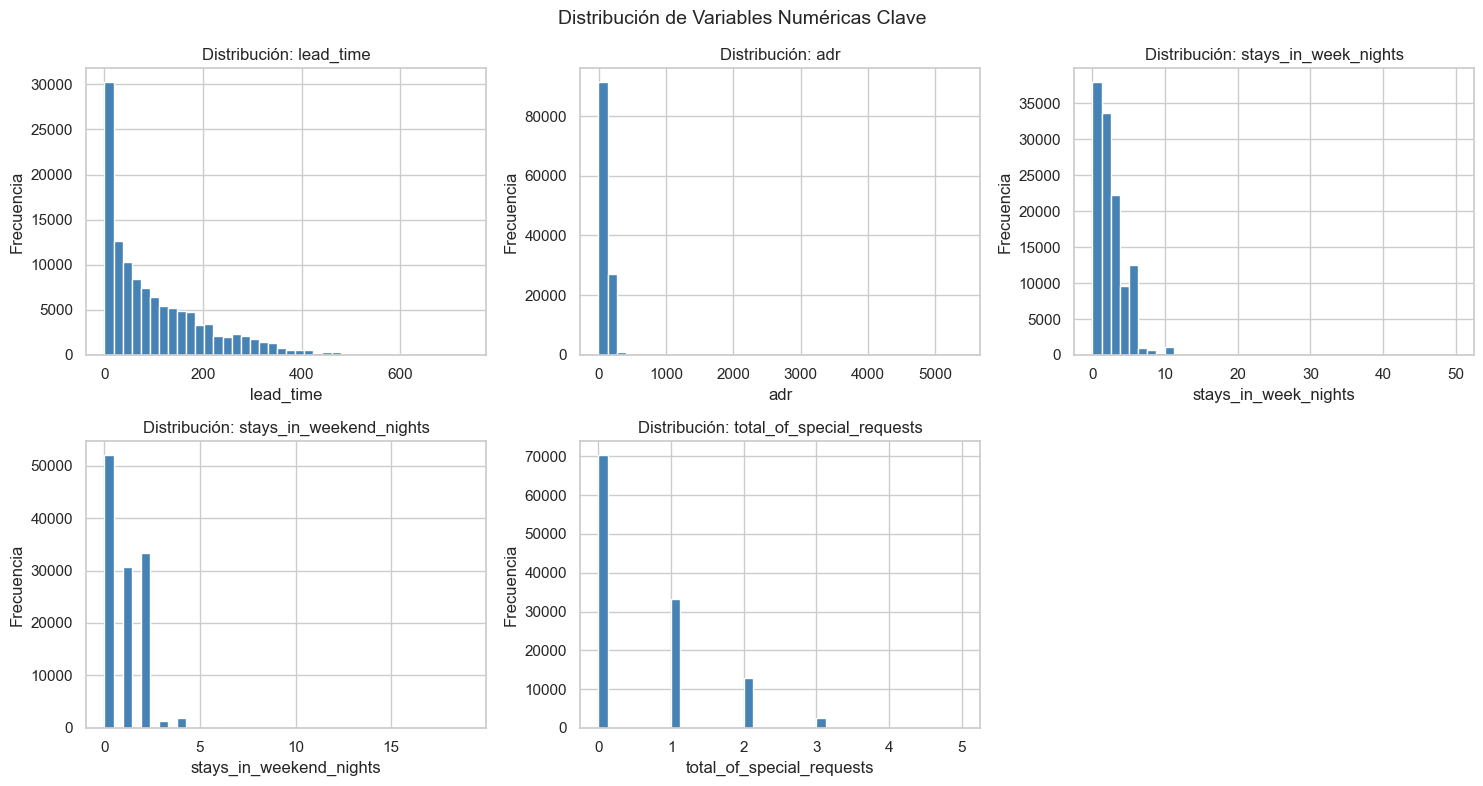

In [22]:
# 3.1 Histogramas de variables numéricas clave
num_cols = ['lead_time', 'adr', 'stays_in_week_nights', 
            'stays_in_weekend_nights', 'total_of_special_requests']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

axes[5].set_visible(False)
plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=14)
plt.tight_layout()
plt.show()

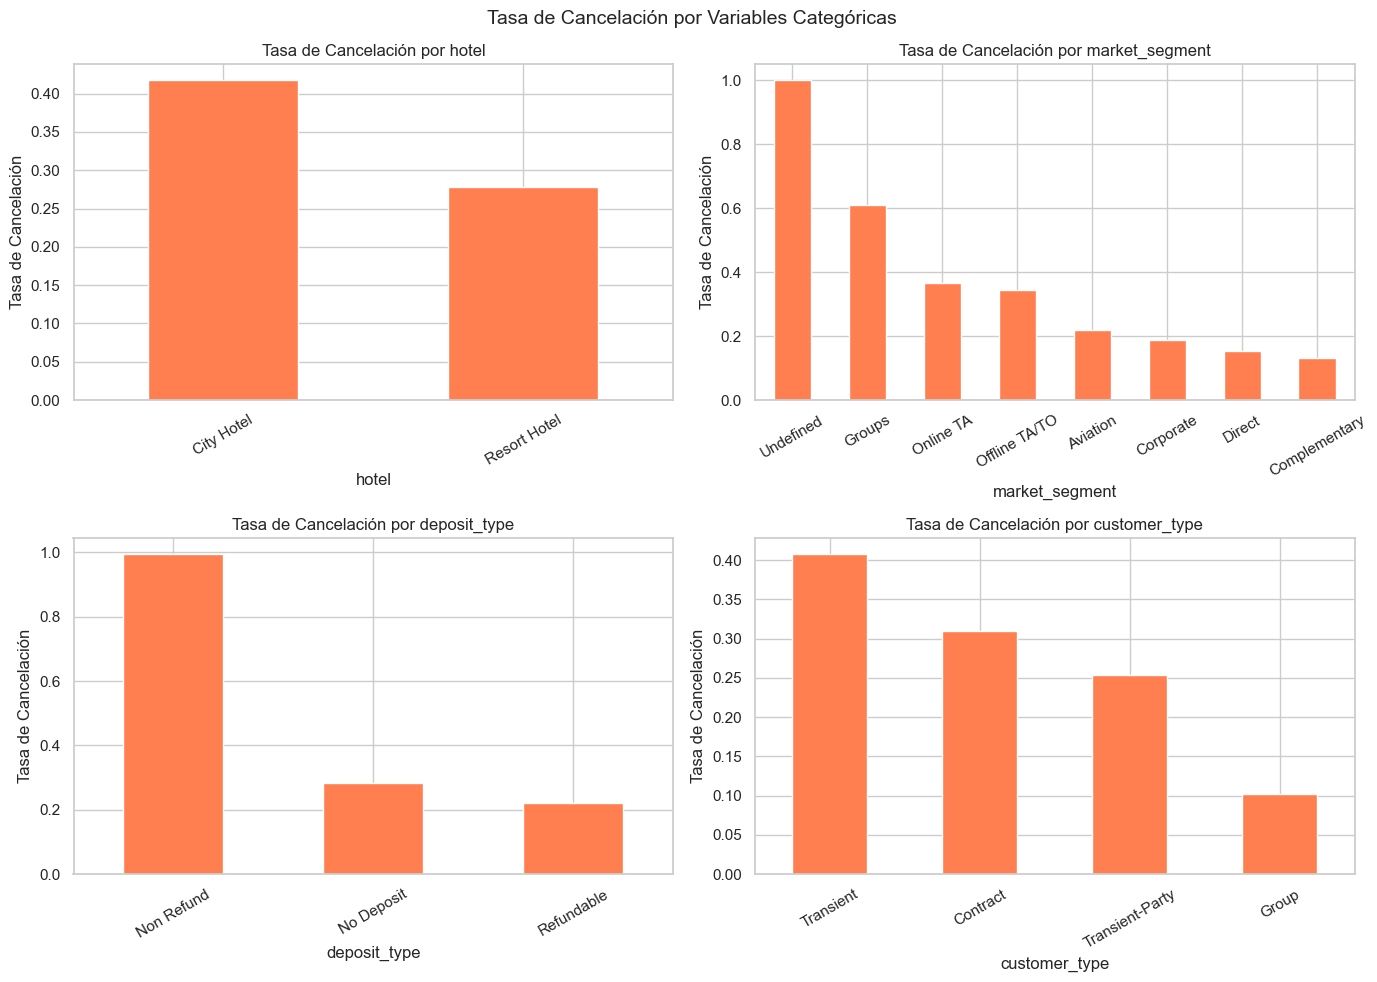

In [27]:
# 3.3 Variables categóricas vs target
cat_importantes = ['hotel', 'market_segment', 'deposit_type', 'customer_type']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_importantes):
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    cancel_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title(f'Tasa de Cancelación por {col}')
    ax.set_ylabel('Tasa de Cancelación')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Tasa de Cancelación por Variables Categóricas', fontsize=14)
plt.tight_layout()
plt.show()

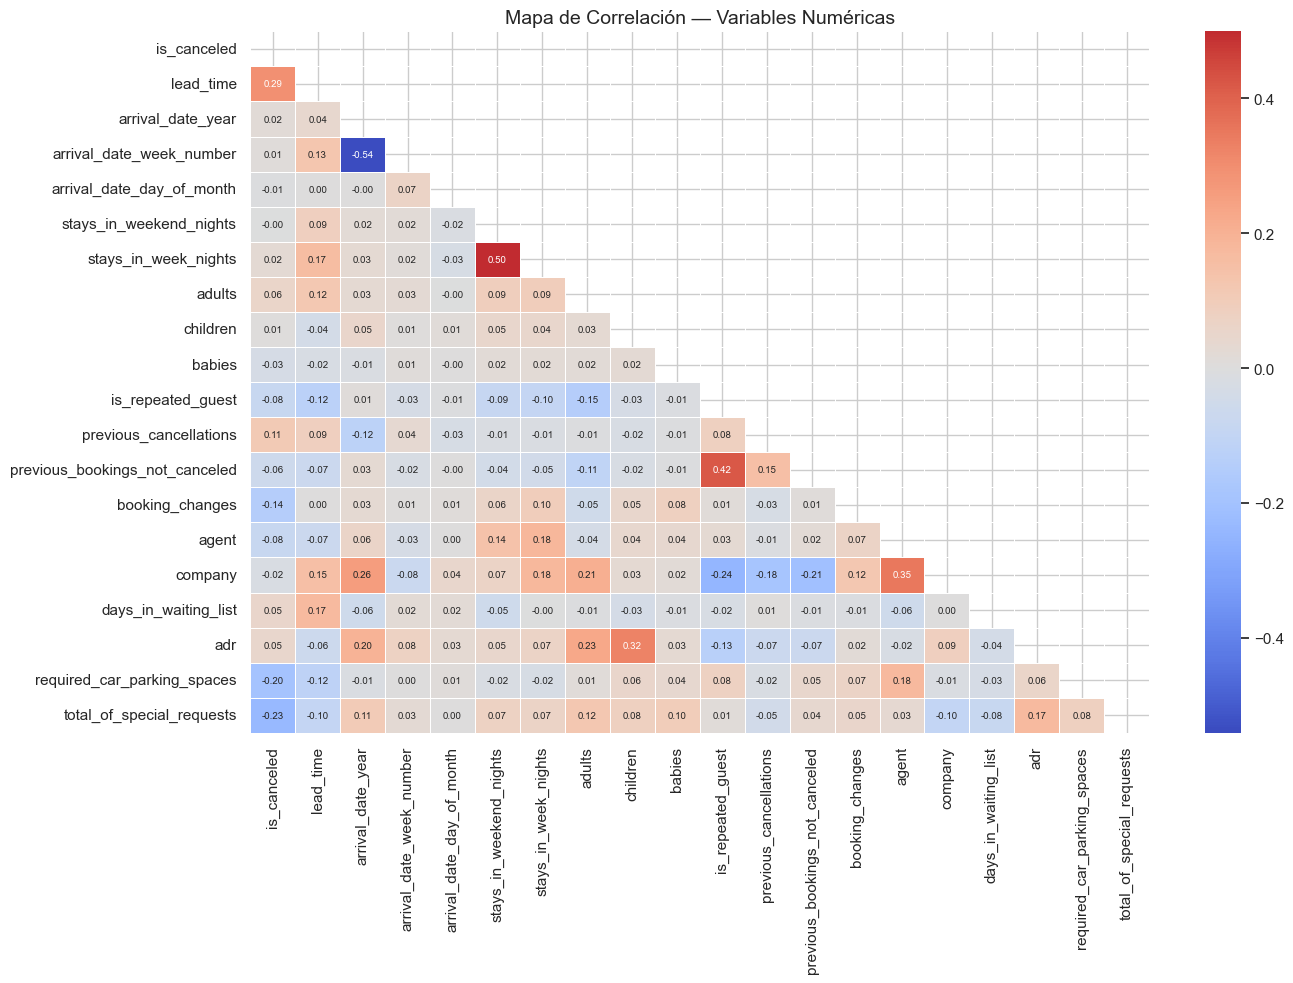

In [28]:
# 3.4 Heatmap de correlación (solo numéricas)
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Mapa de Correlación — Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

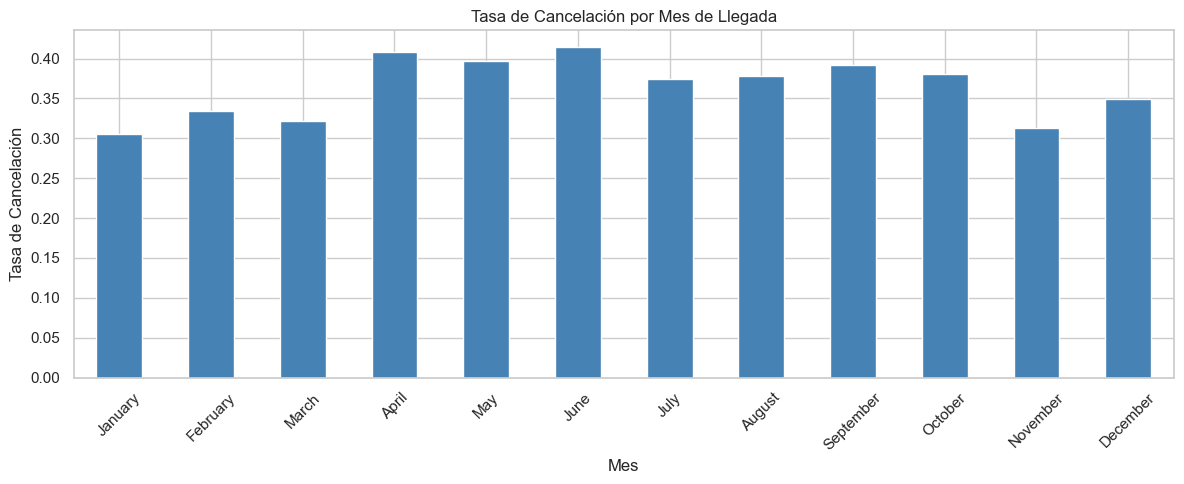

In [29]:
# 3.5 Patrón temporal: cancelaciones por mes
cancel_mes = df.groupby('arrival_date_month')['is_canceled'].mean()

orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
cancel_mes = cancel_mes.reindex(orden_meses)

plt.figure(figsize=(12, 5))
cancel_mes.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Tasa de Cancelación por Mes de Llegada')
plt.xlabel('Mes')
plt.ylabel('Tasa de Cancelación')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

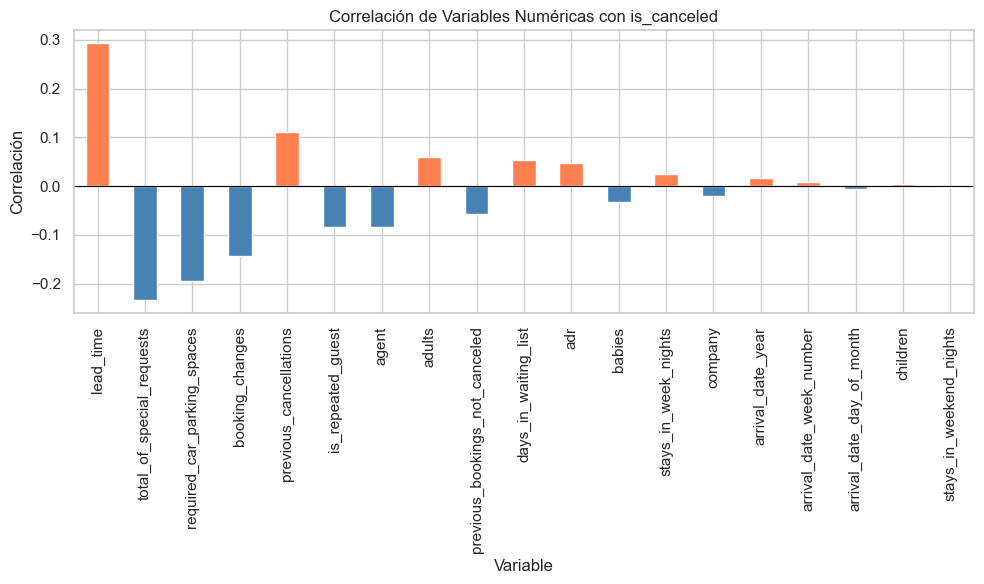

In [30]:
# 3.6 Correlación de variables numéricas con el target
corr_target = df.select_dtypes(include=np.number).corr()['is_canceled'].drop('is_canceled')
corr_target = corr_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
corr_target.plot(kind='bar', color=['coral' if x > 0 else 'steelblue' for x in corr_target])
plt.title('Correlación de Variables Numéricas con is_canceled')
plt.xlabel('Variable')
plt.ylabel('Correlación')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Resumen de Hallazgos del EDA

### Calidad
- 4 columnas con nulos: `company` (94%), `agent` (14%), `country` (0.4%), `children` (0.003%)
- No hay columnas constantes ni duplicados significativos

### Target
- Dataset moderadamente desbalanceado: ~63% no canceló, ~37% canceló

### Variables más relevantes (correlación con target)
- `lead_time`: reservas con más anticipación tienden más a cancelarse
- `deposit_type`: depósitos no reembolsables correlacionan fuertemente con cancelación
- `total_of_special_requests`: más solicitudes especiales → menos cancelaciones
- `adr` (precio promedio por noche): precios más altos correlacionan con más cancelaciones

### Patrones temporales
- La tasa de cancelación varía por mes — picos en ciertos meses que el modelo deberá capturar

### Para Sprint 2 (Data Preparation)
- Tratar nulos de `company`, `agent`, `country`, `children`
- Evaluar encoding de variables categóricas
- Considerar balanceo de clases